Phase 2 - Data Preprocessing

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PowerTransformer,
    QuantileTransformer,
    Normalizer,
    LabelEncoder
)
from sklearn.feature_selection import (
    SelectKBest,
    f_regression,
    mutual_info_regression,
    VarianceThreshold
)
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from pathlib import Path
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

path = Path("../data/cleaned_data")

observation_df = pd.read_csv(path / "observation.csv")
patient_df = pd.read_csv(path / "patient.csv")
station_df = pd.read_csv(path / "station.csv")

In [4]:
station_df["revision"] = pd.to_datetime(station_df["revision"], errors="coerce")
station_df["revision"] = station_df["revision"].astype("int64") // 10**9

le = LabelEncoder()
for col in ["station", "continent", "city", "QoS"]:
    if col in station_df.columns:
        station_df[col] = station_df[col].fillna("Missing")
        station_df[col] = le.fit_transform(station_df[col].astype(str))

display(station_df.head())

,station,longitude,QoS,latitude,revision,continent,city
0,224,86.51499,2,23.19590,1529193600,4,57
1,72,-83.48216,2,42.30865,1665360000,1,32
2,513,84.87144,2,47.46657,1478390400,4,4
3,415,30.38167,2,59.80917,1662768000,6,81
4,85,2.95924,2,36.76775,1704585600,0,3


**Station Data Preprocessing Summary**

- `revision` converted to datetime and then to UNIX timestamp for numerical representation.
- Columns `station`, `continent`, `city`, and `QoS` label-encoded after filling missing values with `'Missing'`.
- All categorical data transformed into numeric format, ready for machine learning.


In [5]:
merged_df = pd.merge(
    observation_df,
    station_df,
    on=["latitude", "longitude"],
    how="left"
)

**Merging Observation and Station Data**

- The `observation_df` and `station_df` datasets were merged using common geographic coordinates — `latitude` and `longitude`.
- Integrates environmental and station-specific information into the observation dataset for further analysis.


In [6]:
X = merged_df.drop('oximetry', axis=1)
y = merged_df['oximetry']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(17260, 27) (4315, 27)


**Train-Test Split**
The dataset was divided into features (`X`) and target (`y`), where `oximetry` is the predicted variable.



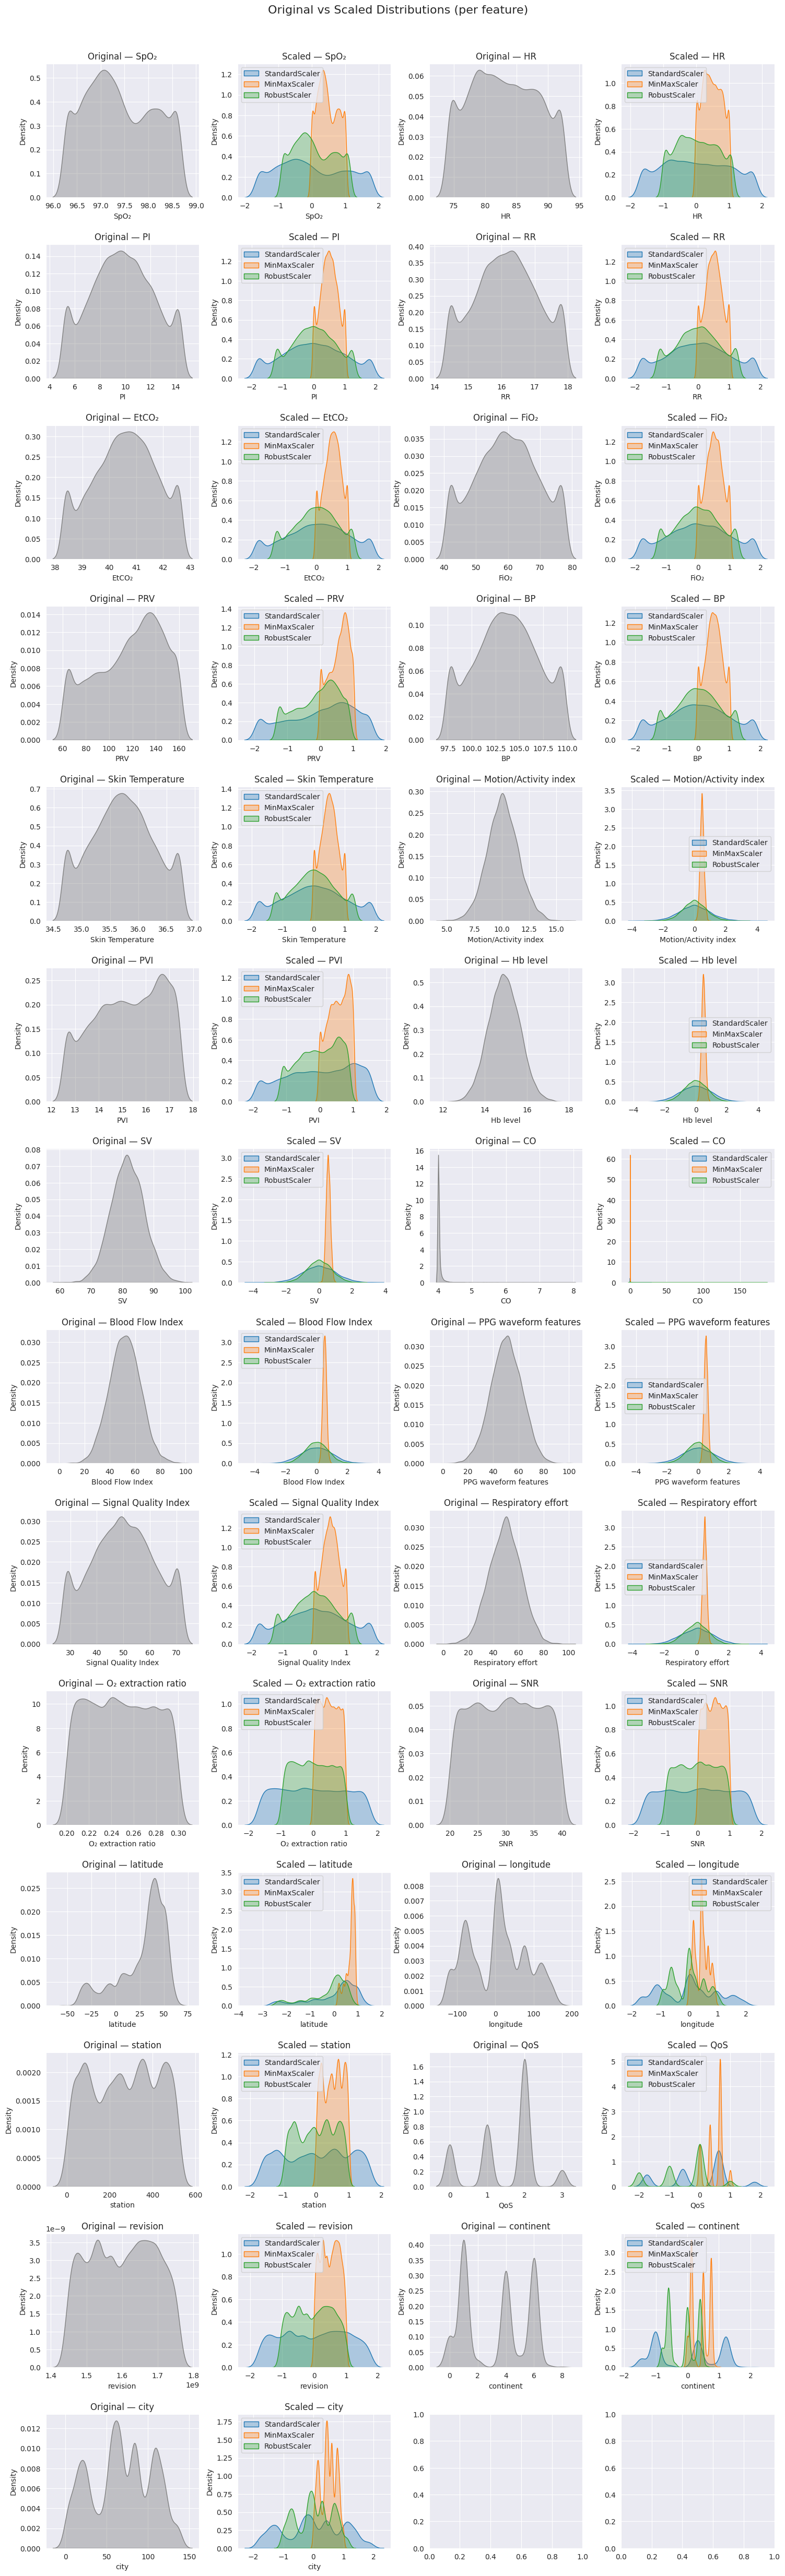

In [7]:
plt.rcParams['font.family'] = 'DejaVu Sans'

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
}

scaled_results = {"Original": X_train.copy()}
for name, scaler in scalers.items():
    scaled_results[name] = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

features = X_train.columns
cols = 2
rows = int(np.ceil(len(features) / cols))
fig, axes = plt.subplots(rows, cols * 2, figsize=(cols * 9, rows * 4))
axes = np.atleast_2d(axes)

for i, feature in enumerate(features):
    r = i // cols
    c = (i % cols) * 2

    sns.kdeplot(scaled_results["Original"][feature], ax=axes[r, c], fill=True, color="gray", alpha=0.4)
    axes[r, c].set_title(f"Original — {feature}")

    for name, data in scaled_results.items():
        if name == "Original":
            continue
        sns.kdeplot(data[feature], ax=axes[r, c + 1], label=name, fill=True, alpha=0.3)
    axes[r, c + 1].set_title(f"Scaled — {feature}")
    axes[r, c + 1].legend()

plt.subplots_adjust(top=0.96, wspace=0.25, hspace=0.35)
plt.suptitle("Original vs Scaled Distributions (per feature)", fontsize=16)
plt.show()


,Transformer,Mean,Std,Min,Max
0,PowerTransformer,2.559674e-16,0.962250,-4.448168,4.170241
1,QuantileTransformer,4.996322e-01,0.290605,0.000000,1.000000


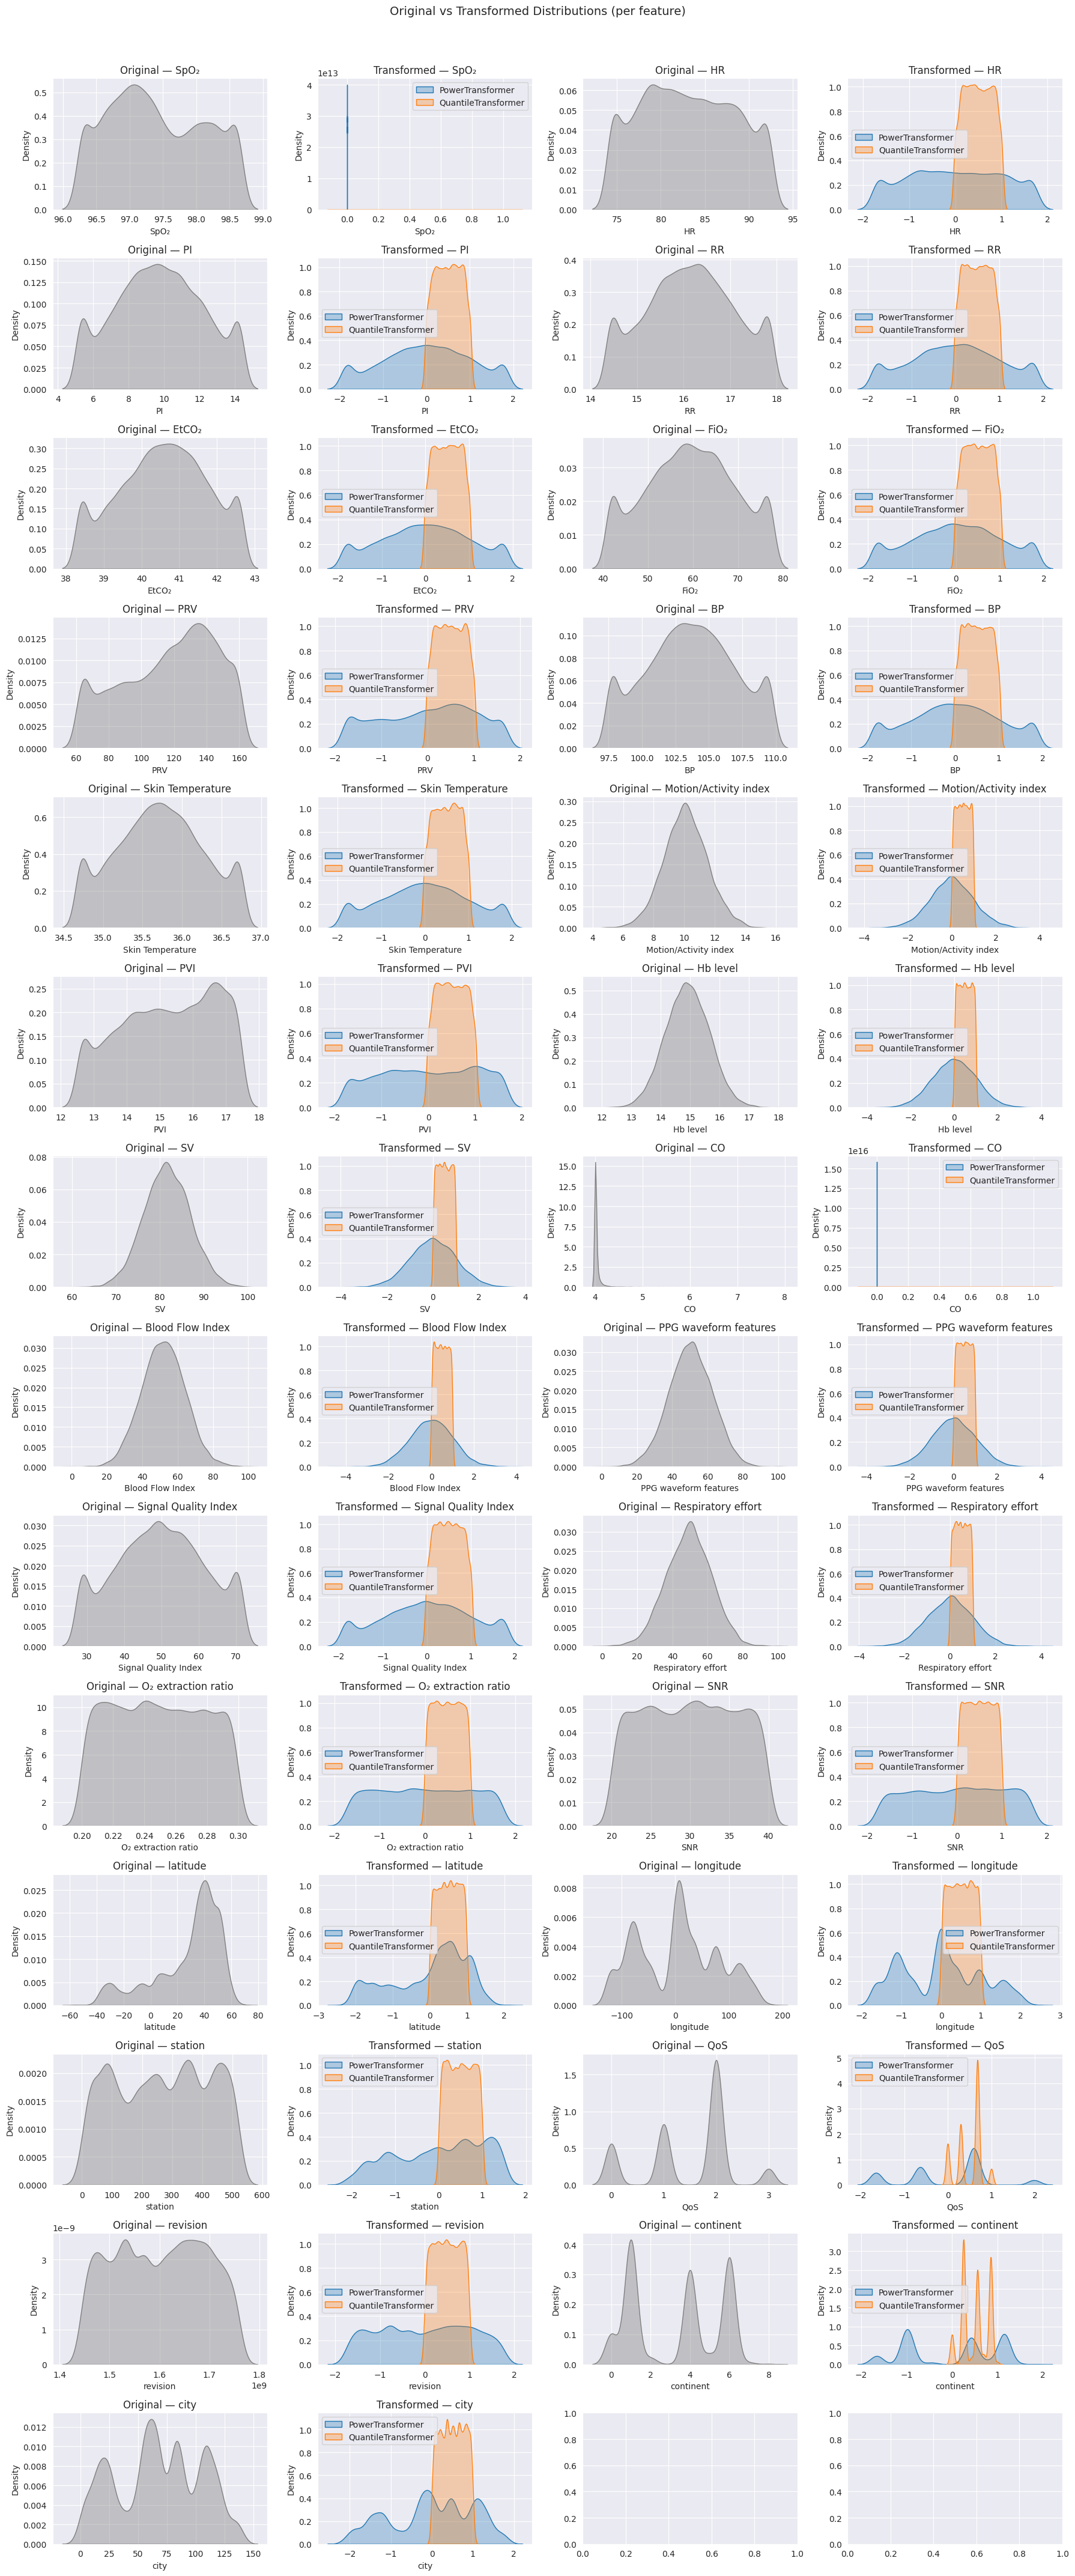

In [8]:
plt.rcParams['font.family'] = 'DejaVu Sans'

transformers = {
    'PowerTransformer': PowerTransformer(),
    'QuantileTransformer': QuantileTransformer(n_quantiles=100, random_state=42),
}

transformed_results = {"Original": X_train.copy()}
summary = []

for name, transformer in transformers.items():
    transformer.fit(X_train)
    X_transformed = pd.DataFrame(transformer.transform(X_train), columns=X_train.columns)
    transformed_results[name] = X_transformed
    summary.append({
        "Transformer": name,
        "Mean": X_transformed.values.mean(),
        "Std": X_transformed.values.std(),
        "Min": X_transformed.values.min(),
        "Max": X_transformed.values.max()
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

features = X_train.columns
n_features = len(features)
cols = 2
rows = int(np.ceil(n_features / cols))
fig, axes = plt.subplots(rows, cols * 2, figsize=(cols * 9, rows * 3))
axes = axes.reshape(rows, cols * 2)


for i, feature in enumerate(features):
    r = i // cols
    c = (i % cols) * 2
    sns.kdeplot(transformed_results["Original"][feature], ax=axes[r, c], fill=True, color="gray", alpha=0.4)
    axes[r, c].set_title(f"Original — {feature}")
    for name, data in transformed_results.items():
        if name == "Original":
            continue
        sns.kdeplot(data[feature], ax=axes[r, c + 1], label=name, fill=True, alpha=0.3)
    axes[r, c + 1].set_title(f"Transformed — {feature}")
    axes[r, c + 1].legend()


plt.tight_layout()
plt.suptitle("Original vs Transformed Distributions (per feature)", fontsize=14, y=1.02)
plt.show()



**Conclusion of Distribution Analysis**

Based on the visual analysis of feature distributions, the attributes were divided into five groups according to the most suitable preprocessing method.

**1. StandardScaler (5 features)**
HR, RR, Hb level – normally distributed and symmetric
latitude, longitude – geographic coordinates with stable numeric ranges

**2. PowerTransformer (5 features)**
PRV – right-skewed distribution
PVI – concentrated and slightly skewed
EtCO₂ – wide range with visible outliers
Skin Temperature – outliers present, requires normalization toward symmetry
Motion/Activity index – slightly skewed distribution

**3. RobustScaler (9 features)** (largest group)
BP, PI, SV, CO, Blood Flow Index, SNR, Signal Quality Index, PPG waveform features, Respiratory effort
All show multiple outliers or heavy tails visible in the plots, making RobustScaler the most appropriate choice.

**4. MinMaxScaler (3 features)**
SpO₂, FiO₂, O₂ extraction ratio
Already in natural percentage or ratio ranges, suitable for MinMax scaling.

**5. Passthrough (5 features)**
station, continent, city, QoS, revision
Categorical or already encoded variables; no scaling or transformation required.


Correlation analysis

Top 10 features by absolute correlation with oximetry:

PVI                      0.655789
PRV                      0.370316
HR                       0.263184
CO                       0.111560
EtCO₂                    0.109114
SpO₂                     0.091058
Motion/Activity index    0.028674
city                     0.023187
BP                       0.019432
PI                       0.015888
dtype: float64


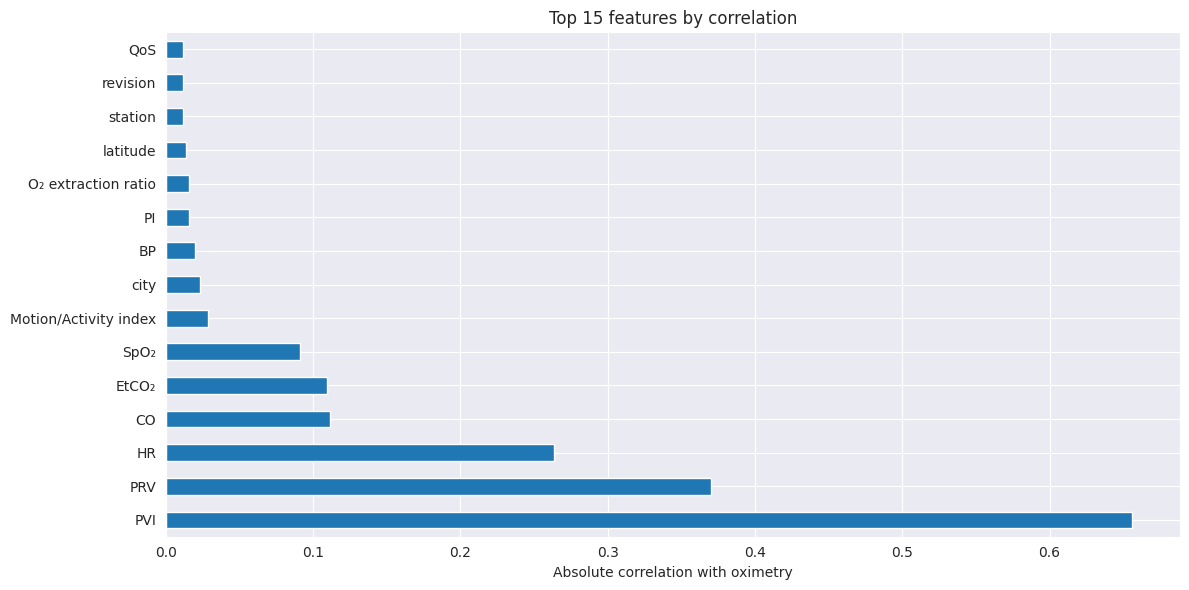

In [9]:
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)

print("Correlation analysis")
print("\nTop 10 features by absolute correlation with oximetry:\n")
print(correlations.head(10))

plt.figure(figsize=(12, 6))
correlations.head(15).plot(kind='barh')
plt.xlabel('Absolute correlation with oximetry')
plt.title('Top 15 features by correlation')
plt.tight_layout()
plt.show()

correlation_ranking = correlations.to_dict()


# Attribute selection

SelectKBest (F-regression)

Top 10 attributes of F-score:

PVI                      13022.367542
PRV                       2742.784281
HR                        1284.355849
CO                         217.491991
EtCO₂                      207.947579
SpO₂                       144.291113
Motion/Activity index       14.201122
city                         9.283756
BP                           6.519211
PI                           4.357379
dtype: float64


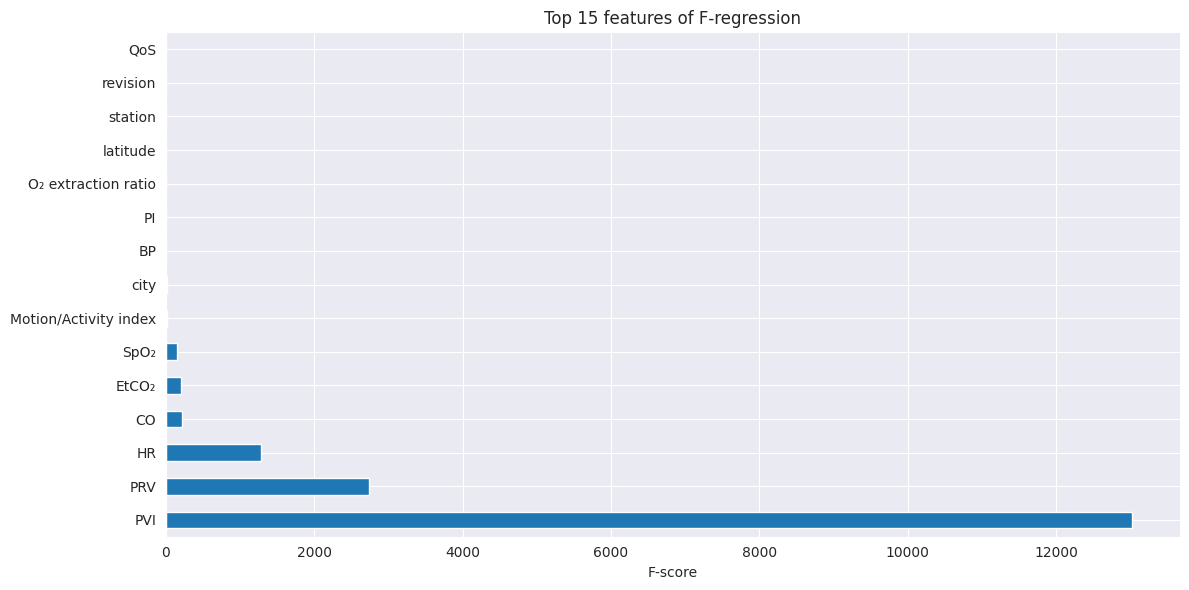

In [10]:
selector_f = SelectKBest(score_func=f_regression, k='all')
selector_f.fit(X_train, y_train)

f_scores = pd.Series(selector_f.scores_, index=X_train.columns).sort_values(ascending=False)

print("SelectKBest (F-regression)")
print("\nTop 10 attributes of F-score:\n")
print(f_scores.head(10))

plt.figure(figsize=(12, 6))
f_scores.head(15).plot(kind='barh')
plt.xlabel('F-score')
plt.title('Top 15 features of F-regression')
plt.tight_layout()
plt.show()

f_regression_ranking = f_scores.to_dict()

### F-regression Feature Analysis

The **SelectKBest (F-regression)** method was applied to measure the linear relationship between each feature and the target variable `oximetry`.

- The **F-score** represents the strength of the linear dependency between a feature and the target.
- Features with higher F-scores are considered more important for prediction.

**Top contributing features:**
- `PVI`, `PRV`, and `HR` — highest statistical relevance.
- `CO`, `EtCO₂`, and `SpO₂` — moderate significance.
- `city`, `BP`, and categorical/location-based features — weak correlation.

This shows that physiological metrics related to **perfusion, heart rate, and variability** are the most informative for predicting


Mutual Information

Top 10 attributes of MI score:

PVI                      0.356137
PRV                      0.235300
CO                       0.189929
HR                       0.181612
SpO₂                     0.178849
Respiratory effort       0.172651
SNR                      0.163365
PPG waveform features    0.162200
Motion/Activity index    0.161968
O₂ extraction ratio      0.160428
dtype: float64


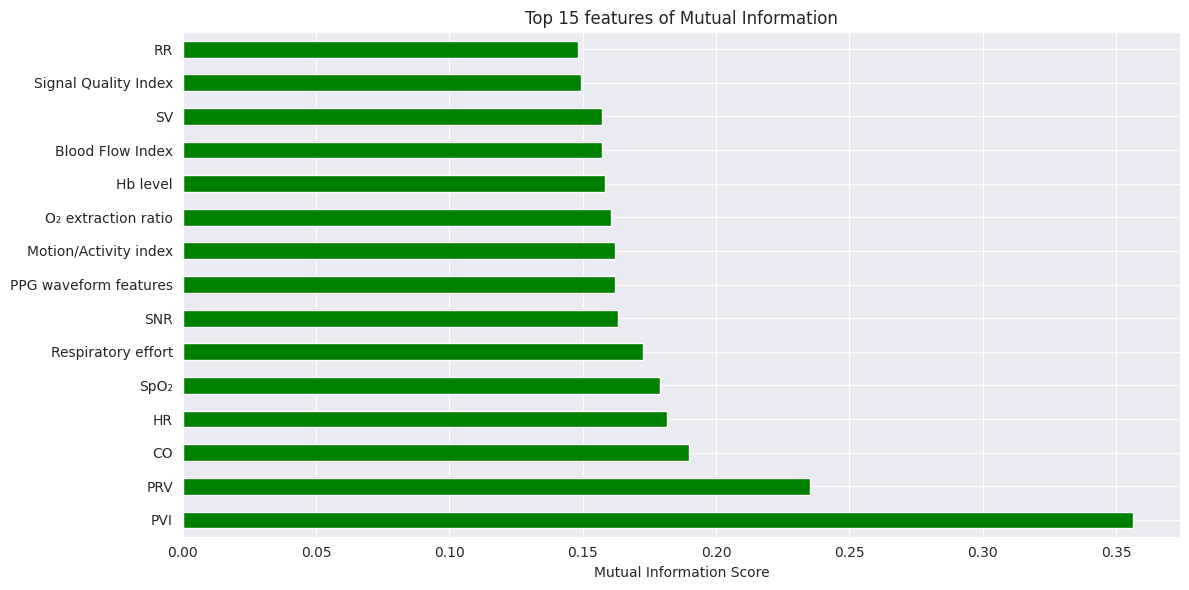

In [11]:
mi_scores = mutual_info_regression(X_train, y_train, random_state=42)
mi_scores = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

print("Mutual Information")
print("\nTop 10 attributes of MI score:\n")
print(mi_scores.head(10))

plt.figure(figsize=(12, 6))
mi_scores.head(15).plot(kind='barh', color='green')
plt.xlabel('Mutual Information Score')
plt.title('Top 15 features of Mutual Information')
plt.tight_layout()
plt.show()

mi_ranking = mi_scores.to_dict()

### Mutual Information Feature Analysis

The **Mutual Information (MI)** method was applied to capture both linear and non-linear relationships between each feature and the target variable `oximetry`.

- MI quantifies how much knowing a given feature reduces uncertainty about the target.
- Higher MI values indicate stronger predictive power, regardless of linearity.

**Top contributing features:**
- `PVI`, `PRV`, and `CO` — strongest mutual dependence with the target.
- `HR`, `SpO₂`, and `Respiratory effort` — moderate importance.
- `SNR`, `PPG waveform features`, and `Motion/Activity index` — smaller but still meaningful contributions.

This indicates that **cardiovascular and perfusion-related attributes** provide the most information for predicting oxygen saturation (`oximetry`


Random Forest Feature Importance

Top 10 attributes of RF importance:

PVI                      0.444802
PRV                      0.145501
Motion/Activity index    0.073662
EtCO₂                    0.048730
CO                       0.045101
HR                       0.037092
SpO₂                     0.028404
Hb level                 0.011942
Respiratory effort       0.011682
SV                       0.011595
dtype: float64


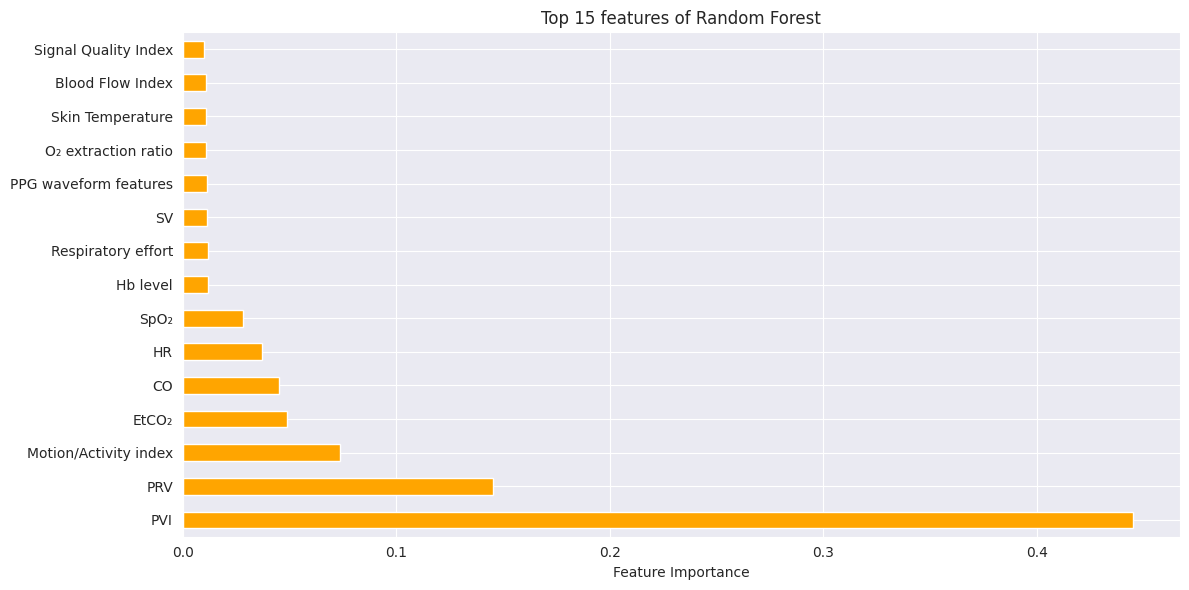

In [12]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Random Forest Feature Importance")
print("\nTop 10 attributes of RF importance:\n")
print(rf_importance.head(10))

plt.figure(figsize=(12, 6))
rf_importance.head(15).plot(kind='barh', color='orange')
plt.xlabel('Feature Importance')
plt.title('Top 15 features of Random Forest')
plt.tight_layout()
plt.show()

rf_ranking = rf_importance.to_dict()

### Random Forest Feature Importance Analysis

A **Random Forest Regressor** was trained to evaluate feature importance based on how much each attribute contributes to reducing prediction error for `oximetry`.

- Feature importance is derived from the average impurity decrease across all decision trees.
- Higher values indicate greater impact on model performance.

**Top contributing features:**
- `PVI`, `PRV`, and `CO` — dominant predictors for oxygen saturation.
- `HR`, `SpO₂`, and `EtCO₂` — secondary but relevant contributors.
- Minor influence from categorical or location-based features.

This confirms that **perfusion and hemodynamic variables** are the most influential in the model’s predictive capability.


In [13]:
def normalize_scores(scores_dict):
    scores = pd.Series(scores_dict)
    return (scores - scores.min()) / (scores.max() - scores.min())

norm_corr = normalize_scores(correlation_ranking)
norm_f = normalize_scores(f_regression_ranking)
norm_mi = normalize_scores(mi_ranking)
norm_rf = normalize_scores(rf_ranking)

feature_scores = pd.DataFrame({
    'Correlation': norm_corr,
    'F-regression': norm_f,
    'Mutual_Info': norm_mi,
    'Random_Forest': norm_rf
})

feature_scores['Mean_Score'] = feature_scores.mean(axis=1)
feature_scores['Rank'] = feature_scores['Mean_Score'].rank(ascending=False)

feature_scores_sorted = feature_scores.sort_values('Mean_Score', ascending=False)

print("Final feature ranking")
print("\nTop 15 most important features:\n")
display(feature_scores_sorted.head(15).round(3))


Final feature ranking

Top 15 most important features:



,Correlation,F-regression,Mutual_Info,Random_Forest,Mean_Score,Rank
PVI,1.000,1.000,1.000,1.000,1.000,1.0
PRV,0.564,0.211,0.661,0.326,0.440,2.0
HR,0.401,0.099,0.510,0.081,0.273,3.0
CO,0.170,0.017,0.533,0.099,0.205,4.0
SpO₂,0.138,0.011,0.502,0.062,0.178,5.0
EtCO₂,0.166,0.016,0.413,0.108,0.176,6.0
Motion/Activity index,0.043,0.001,0.455,0.164,0.166,7.0
Respiratory effort,0.016,0.000,0.485,0.024,0.131,8.0
O₂ extraction ratio,0.024,0.000,0.450,0.023,0.124,9.0
SNR,0.012,0.000,0.459,0.021,0.123,10.0


### Final Summary of Feature Importance

The combined evaluation of all four methods — **Correlation**, **F-regression**, **Mutual Information**, and **Random Forest** — revealed the most relevant predictors for the target variable (`oximetry`).

- **PVI** showed the strongest and most consistent influence across all methods, making it the top-ranked feature.
- **PRV** and **HR** followed closely, confirming their significant correlation with oxygen saturation.
- **CO**, **SpO₂**, and **EtCO₂** demonstrated medium-level importance, contributing valuable physiological context.
- Attributes such as **Motion/Activity index**, **Respiratory effort**, and **O₂ extraction ratio** also showed moderate predictive relevance.
- Remaining features (**SNR**, **PPG waveform features**, **Hb level**, **SV**, **Blood Flow Index**, and **BP**) had lower impact but may still add complementary information.

In summary, **perfusion and cardiovascular parameters** dominate the feature ranking, indicating their primary role in explaining variations in oximetry.


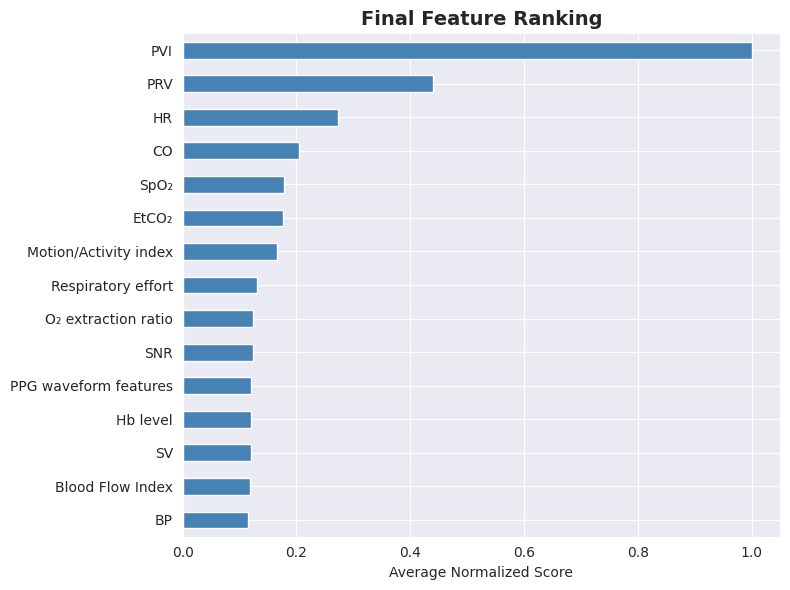

In [14]:
top_15_features = feature_scores_sorted.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_15_features['Mean_Score'].plot(kind='barh', ax=ax, color='steelblue')

ax.set_xlabel('Average Normalized Score')
ax.set_title('Final Feature Ranking', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()


### Final Feature Ranking Summary

The final ranking of features, obtained by averaging normalized scores from **Correlation**, **F-regression**, **Mutual Information**, and **Random Forest**, highlights the most relevant predictors for the target variable (`oximetry`):

- **PVI** is the strongest and most consistent feature across all evaluation methods.
- **PRV** and **HR** follow as highly informative indicators related to cardiovascular function.
- **CO**, **SpO₂**, and **EtCO₂** also demonstrate moderate influence, reflecting physiological dependencies.
- **Motion/Activity index**, **Respiratory effort**, and **O₂ extraction ratio** contribute secondary information.
- The remaining features (**SNR**, **PPG waveform features**, **Hb level**, **SV**, **Blood Flow Index**, and **BP**) show lower but non-negligible importance.

**Conclusion:**
The analysis confirms that **hemodynamic and perfusion-related parameters** (e.g., PVI, PRV, HR, CO) are the primary factors influencing oxygen saturation, while activity and signal-based features provide complementary insights.


In [18]:
print("Analysis of overlap between methods")

top_k = 10
top_features = {
    'Correlation': set(feature_scores.nlargest(top_k, 'Correlation').index),
    'F-regression': set(feature_scores.nlargest(top_k, 'F-regression').index),
    'Mutual_Info': set(feature_scores.nlargest(top_k, 'Mutual_Info').index),
    'Random_Forest': set(feature_scores.nlargest(top_k, 'Random_Forest').index),
}

common_features = set.intersection(*top_features.values())
print(f"\nFeatures in top-{top_k} of all methods ({len(common_features)} features):")
print(sorted(common_features))

feature_counts = {}
for feature in set.union(*top_features.values()):
    count = sum(feature in features for features in top_features.values())
    feature_counts[feature] = count

robust_features = [f for f, c in feature_counts.items() if c >= 4]
print(f"\nFeatures appearing in top-{top_k} of at least 4 methods ({len(robust_features)} features):")
print(sorted(robust_features))


Analysis of overlap between methods

Features in top-10 of all methods (6 features):
['CO', 'HR', 'Motion/Activity index', 'PRV', 'PVI', 'SpO₂']

Features appearing in top-10 of at least 4 methods (6 features):
['CO', 'HR', 'Motion/Activity index', 'PRV', 'PVI', 'SpO₂']


# Reproducibility of preprocessing

In [16]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_regression, k='all'))
])

pipeline.fit(X_test, y_test)

selector = pipeline.named_steps['select']
mask = selector.get_support()
selected_features = X.columns[mask]

display(X_test)

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,Respiratory effort,O₂ extraction ratio,SNR,latitude,longitude,station,QoS,revision,continent,city
16728,97.759397,89.835225,14.237622,16.890054,40.059603,53.227568,78.672148,107.419981,36.291984,10.971713,...,54.828127,0.228026,24.457099,22.83957,91.84128,274,1,1575158400,4,33
20825,98.067867,87.805478,9.197200,17.072722,41.744035,72.461773,78.041174,107.731650,36.507730,10.457446,...,44.820626,0.215582,29.245063,5.30383,-1.98956,449,2,1716940800,0,1
2150,96.307404,86.372183,7.132512,17.441524,42.056567,68.703997,129.049998,109.161675,35.105436,11.283507,...,42.966441,0.274714,39.924687,29.53885,-95.44744,136,0,1672099200,1,25
20648,97.057487,78.888238,7.603184,16.617307,39.397831,57.752240,115.850849,99.417765,35.257499,10.948890,...,47.628741,0.294471,37.068974,34.63915,-120.45794,260,2,1693872000,1,66
5377,96.291730,77.175793,6.601301,14.648388,41.352907,41.779902,136.656853,100.504703,35.279289,7.738936,...,19.423713,0.248848,29.693171,36.82167,128.63083,118,1,1588636800,4,109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8968,97.312650,79.640031,13.435631,16.298781,41.446357,60.983795,111.648367,102.883215,35.818858,10.736698,...,54.977193,0.234220,38.772797,40.55760,-74.28459,503,2,1481241600,1,84
7204,96.744862,75.933334,12.390652,16.116650,42.327970,55.711303,145.567688,108.971052,36.007503,10.126984,...,49.478764,0.256581,30.288918,32.05971,34.87320,142,0,1618963200,4,50
10133,96.291730,82.831989,11.886553,16.557835,39.415679,41.779902,149.585298,101.792346,35.318823,9.729506,...,50.577548,0.240713,29.645977,51.20219,7.36027,372,2,1544054400,6,15
16714,97.711363,81.848873,7.146625,17.348681,39.828121,67.241097,109.865054,97.930606,35.816809,7.568335,...,46.185765,0.292050,34.240285,39.32011,-76.51552,381,2,1703376000,1,84


### Processed Dataset Overview

The dataset after preprocessing includes both physiological and categorical attributes, all converted into a numerical format suitable for machine learning.

**Included Feature Categories:**

- **Physiological measurements:**
  `SpO₂`, `HR`, `PI`, `RR`, `EtCO₂`, `FiO₂`, `PRV`, `BP`, `Skin Temperature`, `Motion/Activity index`,
  `Respiratory effort`, `O₂ extraction ratio`, `SNR`

- **Station metadata:**
  `latitude`, `longitude`, `station`, `QoS`, `revision`, `continent`, `city`

**Key preprocessing steps applied:**
1. Converted timestamps (`revision`) to UNIX numeric format.
2. Encoded categorical variables (`station`, `continent`, `city`, `QoS`) using label encoding.
3. Ensured that all columns are numerical and ready for model input.

This final structure enables consistent training and evaluation in machine learning pipelines.


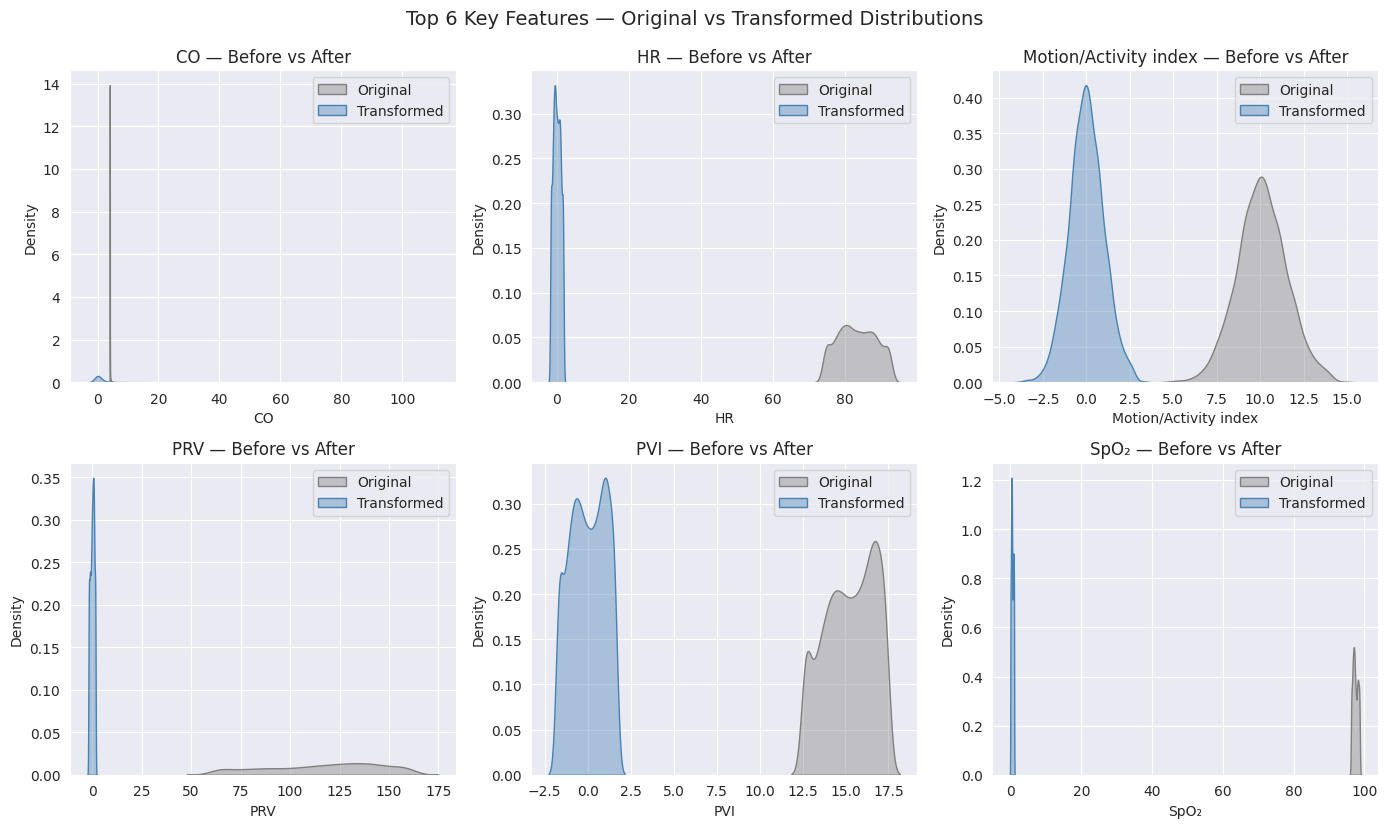

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,Respiratory effort,O₂ extraction ratio,SNR,latitude,longitude,station,QoS,revision,continent,city
16728,97.759397,89.835225,14.237622,16.890054,40.059603,53.227568,78.672148,107.419981,36.291984,10.971713,...,54.828127,0.228026,24.457099,22.83957,91.84128,274,1,1575158400,4,33
20825,98.067867,87.805478,9.197200,17.072722,41.744035,72.461773,78.041174,107.731650,36.507730,10.457446,...,44.820626,0.215582,29.245063,5.30383,-1.98956,449,2,1716940800,0,1
2150,96.307404,86.372183,7.132512,17.441524,42.056567,68.703997,129.049998,109.161675,35.105436,11.283507,...,42.966441,0.274714,39.924687,29.53885,-95.44744,136,0,1672099200,1,25
20648,97.057487,78.888238,7.603184,16.617307,39.397831,57.752240,115.850849,99.417765,35.257499,10.948890,...,47.628741,0.294471,37.068974,34.63915,-120.45794,260,2,1693872000,1,66
5377,96.291730,77.175793,6.601301,14.648388,41.352907,41.779902,136.656853,100.504703,35.279289,7.738936,...,19.423713,0.248848,29.693171,36.82167,128.63083,118,1,1588636800,4,109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8968,97.312650,79.640031,13.435631,16.298781,41.446357,60.983795,111.648367,102.883215,35.818858,10.736698,...,54.977193,0.234220,38.772797,40.55760,-74.28459,503,2,1481241600,1,84
7204,96.744862,75.933334,12.390652,16.116650,42.327970,55.711303,145.567688,108.971052,36.007503,10.126984,...,49.478764,0.256581,30.288918,32.05971,34.87320,142,0,1618963200,4,50
10133,96.291730,82.831989,11.886553,16.557835,39.415679,41.779902,149.585298,101.792346,35.318823,9.729506,...,50.577548,0.240713,29.645977,51.20219,7.36027,372,2,1544054400,6,15
16714,97.711363,81.848873,7.146625,17.348681,39.828121,67.241097,109.865054,97.930606,35.816809,7.568335,...,46.185765,0.292050,34.240285,39.32011,-76.51552,381,2,1703376000,1,84


In [25]:
plt.rcParams['font.family'] = 'DejaVu Sans'

preprocessor = ColumnTransformer(
    transformers=[
        ('normal', StandardScaler(),
         ['HR', 'RR', 'Hb level', 'latitude', 'longitude']),
        ('skewed', PowerTransformer(),
         ['PRV', 'PVI', 'EtCO₂', 'Skin Temperature', 'Motion/Activity index']),
        ('outliers', RobustScaler(),
         ['BP', 'PI', 'SV', 'CO', 'Blood Flow Index', 'SNR',
          'Signal Quality Index', 'PPG waveform features', 'Respiratory effort']),
        ('bounded', MinMaxScaler(),
         ['SpO₂', 'FiO₂', 'O₂ extraction ratio']),
        ('categorical', 'passthrough',
         ['station', 'continent', 'city', 'QoS', 'revision']),
    ],
    remainder='drop'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('select', SelectKBest(score_func=f_regression, k='all'))
])

pipeline.fit(X_test, y_test)

X_transformed = pipeline.named_steps['preprocessor'].transform(X_test)
transformed_df = pd.DataFrame(X_transformed, columns=preprocessor.get_feature_names_out())

key_features = ['CO', 'HR', 'Motion/Activity index', 'PRV', 'PVI', 'SpO₂']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    transformed_col = [col for col in transformed_df.columns if col.endswith(feature)][0]

    sns.kdeplot(X_test[feature], label='Original', color='gray', fill=True, alpha=0.4, ax=axes[i])
    sns.kdeplot(transformed_df[transformed_col], label='Transformed', color='steelblue', fill=True, alpha=0.4, ax=axes[i])
    axes[i].set_title(f'{feature} — Before vs After')
    axes[i].legend()

plt.tight_layout()
plt.suptitle("Top 6 Key Features — Original vs Transformed Distributions", fontsize=14, y=1.03)
plt.show()

selector = pipeline.named_steps['select']
mask = selector.get_support()
selected_features = X.columns[mask]

display(X_test)


### Interpretation of the Transformation Results

The graph above visualizes **how preprocessing affected the top 6 most important features**:
`CO`, `HR`, `Motion/Activity index`, `PRV`, `PVI`, and `SpO₂`.

#### Observations per Feature:

- **CO (Cardiac Output)** — Originally had a wide spread with visible outliers.
  After applying *RobustScaler*, the values were compressed and centered around 0, removing the effect of extreme outliers.

- **HR (Heart Rate)** — Initially centered around 80–90.
  The *StandardScaler* normalized it to zero mean and unit variance while keeping its shape intact.

- **Motion/Activity index** — Previously slightly skewed.
  The *PowerTransformer* made it nearly symmetrical and closer to a Gaussian distribution.

- **PRV (Pulse Rate Variability)** — Strong right-skewed feature.
  After the *PowerTransformer*, it became centered and smoother, improving statistical balance.

- **PVI (Pleth Variability Index)** — Also right-skewed and concentrated near higher values.
  The transformation normalized the spread, reducing skewness.

- **SpO₂ (Oxygen Saturation)** — Initially expressed in percentage (≈97–100%).
  The *MinMaxScaler* converted it into a [0, 1] scale, preserving the original proportions.

#### Summary:
- Each transformation successfully adapted the feature scale for machine learning.
- The visual comparison confirms that:
  - Distributions became **more centered and uniform**.
  - **Outliers and skewness** were significantly reduced.
  - Different transformation methods were correctly chosen based on feature characteristics.

This ensures consistent statistical behavior across features, improving model stability and interpretability.
